**HEART** **DISEASE** **PREDICTION**

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report, roc_auc_score, roc_curve

1.Load Data

2.Import Libraries

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [218]:
import pandas as pd
df = pd.read_csv("cleveland_raw.csv")
df.head()

,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [168]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    "processed.hungarian.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

In [169]:
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv('cleveland_raw.csv', names=cols, na_values='?')

print("Shape:", df.shape)
print(df.head())
print(df.info())



Shape: (303, 14)
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 

3. Clean the data

In [170]:
# ca and thal have a few missing values -> fill with the most frequent value (mode)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Convert target to binary: 0 = no disease, 1 = disease present (was 1,2,3,4)
df['target'] = (df['target'] > 0).astype(int)

print("\nBinary target distribution:")
print(df['target'].value_counts())


Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64


4.EDA

In [171]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')
plt.savefig('eda_target_distribution.png', dpi=100, bbox_inches='tight')
plt.close()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.close()

print("\nSaved EDA plots: eda_target_distribution.png, eda_correlation_heatmap.png")


Saved EDA plots: eda_target_distribution.png, eda_correlation_heatmap.png


5.Split Features & Target




In [172]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (helps Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

6.Train models

In [173]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc
    }

    print(f"\n=== {name} ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}  <-- most important: catches actual disease cases")
    print(f"F1 Score:  {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    print(classification_report(y_test, y_pred))


=== Logistic Regression ===
Accuracy:  0.869
Precision: 0.812
Recall:    0.929  <-- most important: catches actual disease cases
F1 Score:  0.867
ROC-AUC:   0.951
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


=== Random Forest ===
Accuracy:  0.902
Precision: 0.844
Recall:    0.964  <-- most important: catches actual disease cases
F1 Score:  0.900
ROC-AUC:   0.955
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



7.Compare Result

In [174]:
results_df = pd.DataFrame(results).T
print("\n=== Model Comparison ===")
print(results_df)
results_df.to_csv('model_comparison.csv')


=== Model Comparison ===
                     accuracy  precision    recall        f1       auc
Logistic Regression  0.868852    0.81250  0.928571  0.866667  0.951299
Random Forest        0.901639    0.84375  0.964286  0.900000  0.954545


8.Important features(Random Forest)

In [175]:
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.close()

print("\nSaved feature_importance.png")
print("\nDone. Files saved: eda_target_distribution.png, eda_correlation_heatmap.png, feature_importance.png, model_comparison.csv")


Saved feature_importance.png

Done. Files saved: eda_target_distribution.png, eda_correlation_heatmap.png, feature_importance.png, model_comparison.csv


Loading three dataset

In [255]:
import pandas as pd

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

hungarian = pd.read_csv(
    "processed.hungarian.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

switzerland = pd.read_csv(
    "processed.switzerland.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

va = pd.read_csv(
    "processed.va.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

FileNotFoundError: [Errno 2] No such file or directory: 'processed.va.data'

In [177]:
print(hungarian.shape)
print(switzerland.shape)
print(va.shape)

(294, 14)
(123, 14)
(200, 14)


Merge dataset

In [178]:
merged = pd.concat([hungarian, switzerland, va], ignore_index=True)

print(merged.shape)

merged.to_csv("heart_disease_merged.csv", index=False)


(617, 14)


In [179]:
# Display all rows and columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(merged)

                                      age  sex  cp  trestbps  chol  fbs  \
0      28,1,2,130,132,0,2,185,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
1      29,1,2,120,243,0,0,160,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
2        29,1,2,140,?,0,0,170,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
3      30,0,1,170,237,0,1,170,0,0,?,?,6,0  NaN NaN       NaN   NaN  NaN   
4      31,0,2,100,219,0,1,150,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
5      32,0,2,105,198,0,0,165,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
6      32,1,2,110,225,0,0,184,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
7      32,1,2,125,254,0,0,155,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
8      33,1,3,120,298,0,0,185,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
9      34,0,2,130,161,0,0,190,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
10     34,1,2,150,214,0,1,168,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
11      34,1,2,98,220,0,0,150,0,0,?,?,?,0  NaN NaN       NaN   NaN  NaN   
12     35,0,1,120,160,0,1

**01_Data_Preprocessing**

Import Libraries

Define Column Names

Load the Dataset

Add Dataset Source

Merge

Check Dataset

Save the Dataset

Basic Information

Summary Statistics

Count Missing Values

In [180]:
#Import Libraries

In [181]:
#Define Column Names
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target" ]

In [254]:
#Load the Datasets
cleveland = pd.read_csv(
    "cleveland_raw.csv",
    sep=",",
    header=None,
    names=columns,
    na_values="?"
)

hungarian = pd.read_csv(
    "processed.hungarian.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

switzerland = pd.read_csv(
    "processed.switzerland.data",
    sep=r"\s+",
    header=None,
    names=columns,
    na_values="?"
)

In [183]:
#Add Dataset Source
cleveland["dataset"] = "Cleveland"
hungarian["dataset"] = "Hungarian"
switzerland["dataset"] = "Switzerland"
va["dataset"] = "VA"

In [184]:
#Merge
heart = pd.concat(
    [cleveland, hungarian, switzerland, va],
    ignore_index=True
)

In [185]:
#Check Dataset
print("Shape:", heart.shape)

heart.head()

Shape: (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0,Cleveland


In [186]:
#Save the Dataset
heart.to_csv("merged_heart_disease.csv", index=False)

In [187]:
#Basic Information
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    object 
 1   sex       720 non-null    float64
 2   cp        720 non-null    float64
 3   trestbps  717 non-null    float64
 4   chol      697 non-null    float64
 5   fbs       637 non-null    float64
 6   restecg   718 non-null    float64
 7   thalach   718 non-null    float64
 8   exang     718 non-null    float64
 9   oldpeak   714 non-null    float64
 10  slope     513 non-null    float64
 11  ca        307 non-null    float64
 12  thal      400 non-null    float64
 13  target    720 non-null    float64
 14  dataset   920 non-null    object 
dtypes: float64(13), object(2)
memory usage: 107.9+ KB


In [188]:
#Summary Statistics
heart.describe()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,720.000000,720.000000,717.000000,697.000000,637.000000,718.000000,718.000000,718.000000,714.000000,513.000000,307.000000,400.000000,720.000000
mean,0.738889,3.179167,131.804742,204.774749,0.109890,0.568245,140.565460,0.337047,0.789636,1.701754,0.680782,4.985000,0.850000
std,0.439546,0.953646,18.529331,109.275156,0.312999,0.833534,25.647172,0.473031,1.066961,0.585249,0.937101,1.929789,1.076878
min,0.000000,1.000000,80.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,0.000000,2.000000,120.000000,182.000000,0.000000,0.000000,122.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,1.000000,4.000000,130.000000,227.000000,0.000000,0.000000,142.000000,0.000000,0.200000,2.000000,0.000000,6.000000,0.500000
75%,1.000000,4.000000,140.000000,270.000000,0.000000,1.000000,160.000000,1.000000,1.500000,2.000000,1.000000,7.000000,1.000000
max,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [189]:
#Count Missing Values
heart.isnull().sum()

,0
age,0
sex,200
cp,200
trestbps,203
chol,223
fbs,283
restecg,202
thalach,202
exang,202
oldpeak,206


Data Cleaning

heck the dataset shape

Check data types

Count missing values

Check duplicates

Check unique values in the target column

Fill missing values Numerical columns

Confirm all missing values are handled

Save the cleaned dataset

In [190]:
#Check the dataset shape
print("Rows and Columns:", heart.shape)

Rows and Columns: (920, 15)


In [191]:
#Check data types
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    object 
 1   sex       720 non-null    float64
 2   cp        720 non-null    float64
 3   trestbps  717 non-null    float64
 4   chol      697 non-null    float64
 5   fbs       637 non-null    float64
 6   restecg   718 non-null    float64
 7   thalach   718 non-null    float64
 8   exang     718 non-null    float64
 9   oldpeak   714 non-null    float64
 10  slope     513 non-null    float64
 11  ca        307 non-null    float64
 12  thal      400 non-null    float64
 13  target    720 non-null    float64
 14  dataset   920 non-null    object 
dtypes: float64(13), object(2)
memory usage: 107.9+ KB


In [192]:
#Count missing values
heart.isnull().sum()

,0
age,0
sex,200
cp,200
trestbps,203
chol,223
fbs,283
restecg,202
thalach,202
exang,202
oldpeak,206


In [193]:
#Check duplicates
print("Duplicate rows:", heart.duplicated().sum())

Duplicate rows: 2


In [194]:
#If duplicates exist:
heart.drop_duplicates(inplace=True)

In [195]:
#Check unique values in the target column
heart["target"].value_counts()

,count
target,
0.0,359
1.0,209
2.0,68
3.0,65
4.0,18


In [196]:
#Convert it to a binary target:
heart["target"] = heart["target"].apply(lambda x: 0 if x == 0 else 1)

In [197]:
#Verify the result:
heart["target"].value_counts()

,count
target,
1,559
0,359


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [220]:
#Categorical columns
cat_cols = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

for col in cat_cols:
    heart[col] = heart[col].fillna(heart[col].mode()[0])


In [221]:
#Confirm all missing values are handled
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,202
chol,221
fbs,0
restecg,0
thalach,201
exang,0
oldpeak,205


In [222]:
#Save the cleaned dataset
heart.to_csv("heart_disease_cleaned.csv", index=False)

Exploratory Data Analysis

Load the cleaned dataset

Dataset Overview

Statistical Summary

Target Distribution

Age Distribution

Gender Distribution

Correlation Matrix

Boxplot (Outlier Detection)

Pairplot (Optional)

Disease by Age

Disease by Cholesterol

Save EDA Insights

In [223]:
#Load the cleaned dataset
heart = pd.read_csv("heart_disease_cleaned.csv")

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


In [224]:
#Dataset Overview
print("Shape:", heart.shape)
print()

heart.info()

Shape: (918, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    object 
 1   sex       918 non-null    float64
 2   cp        918 non-null    float64
 3   trestbps  716 non-null    float64
 4   chol      697 non-null    float64
 5   fbs       918 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   717 non-null    float64
 8   exang     918 non-null    float64
 9   oldpeak   713 non-null    float64
 10  slope     918 non-null    float64
 11  ca        918 non-null    float64
 12  thal      918 non-null    float64
 13  target    918 non-null    int64  
 14  dataset   918 non-null    object 
dtypes: float64(12), int64(1), object(2)
memory usage: 107.7+ KB


In [225]:
#Statistical Summary
heart.describe()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,918.000000,918.000000,716.000000,697.000000,918.000000,918.000000,717.000000,918.000000,713.000000,918.000000,918.000000,918.000000,918.000000
mean,0.796296,3.358388,131.835196,204.774749,0.076253,0.444444,140.538354,0.263617,0.790743,1.833333,0.227669,3.864924,0.608932
std,0.402971,0.908634,18.524320,109.275156,0.265547,0.773517,25.654783,0.440834,1.067299,0.461731,0.629532,1.609422,0.488255
min,0.000000,1.000000,80.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.000000,0.000000,3.000000,0.000000
25%,1.000000,3.000000,120.000000,182.000000,0.000000,0.000000,122.000000,0.000000,0.000000,2.000000,0.000000,3.000000,0.000000
50%,1.000000,4.000000,130.000000,227.000000,0.000000,0.000000,142.000000,0.000000,0.200000,2.000000,0.000000,3.000000,1.000000
75%,1.000000,4.000000,140.000000,270.000000,0.000000,1.000000,160.000000,1.000000,1.500000,2.000000,0.000000,3.000000,1.000000
max,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [227]:
#Target Distribution
#This shows how many patients have heart disease.
heart["target"].value_counts()

,count
target,
1,559
0,359


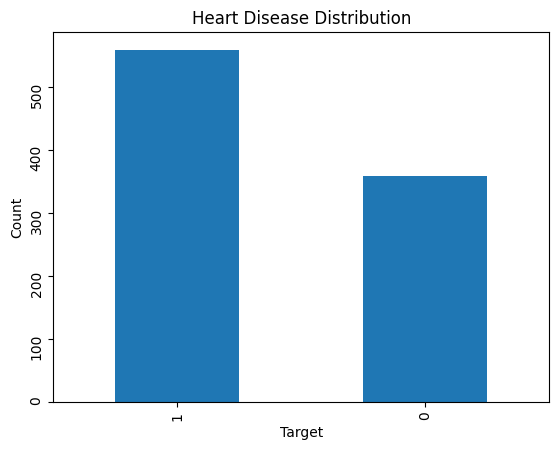

In [228]:
#Plot it:
heart["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.yticks(rotation=90)

plt.show()

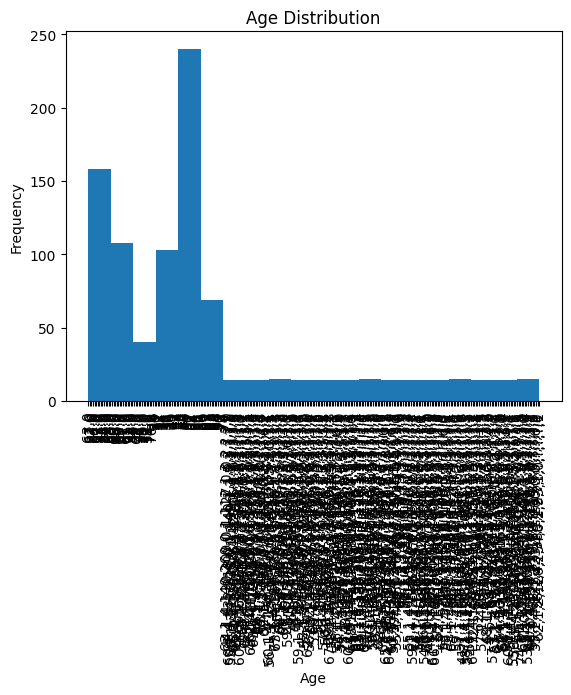

In [229]:
#Age Distribution
plt.hist(heart["age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

plt.show()

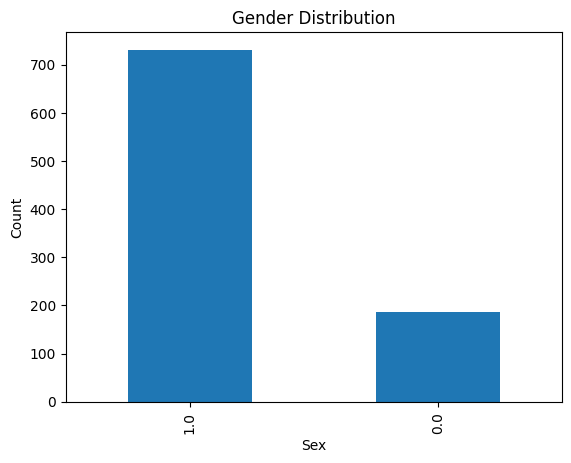

In [230]:
#Gender Distribution
heart["sex"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

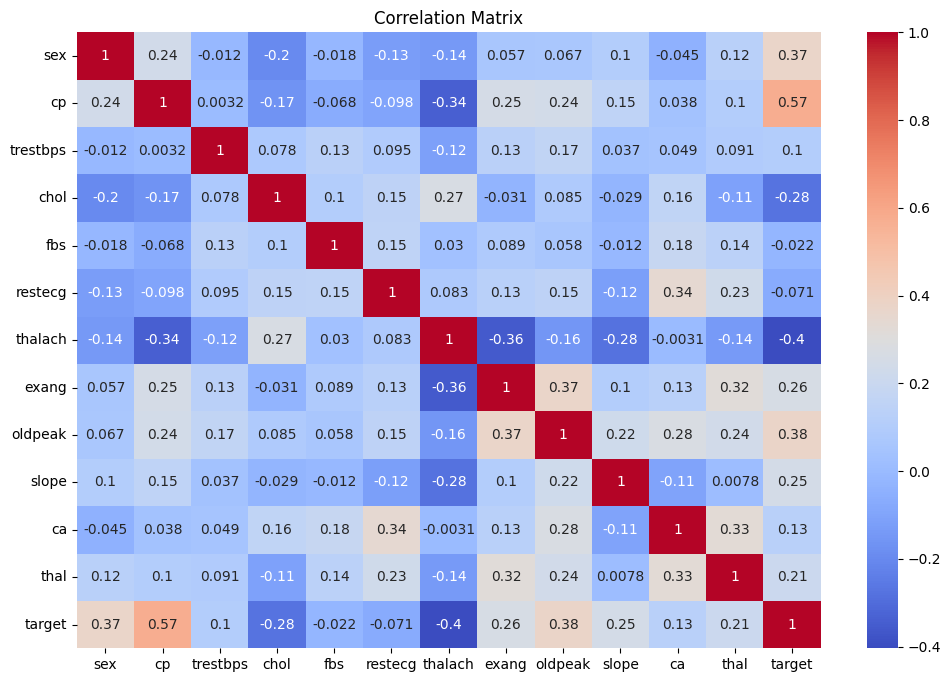

In [231]:
#Correlation Matrix
corr = heart.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

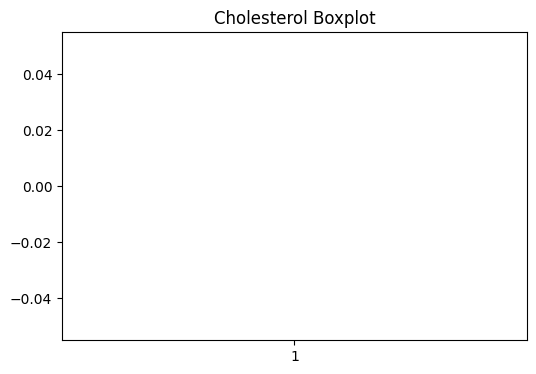

In [232]:
#Boxplot (Outlier Detection)
plt.figure(figsize=(6,4))

plt.boxplot(heart["chol"], patch_artist=True, boxprops=dict(facecolor='red'))

plt.title("Cholesterol Boxplot")

plt.show()

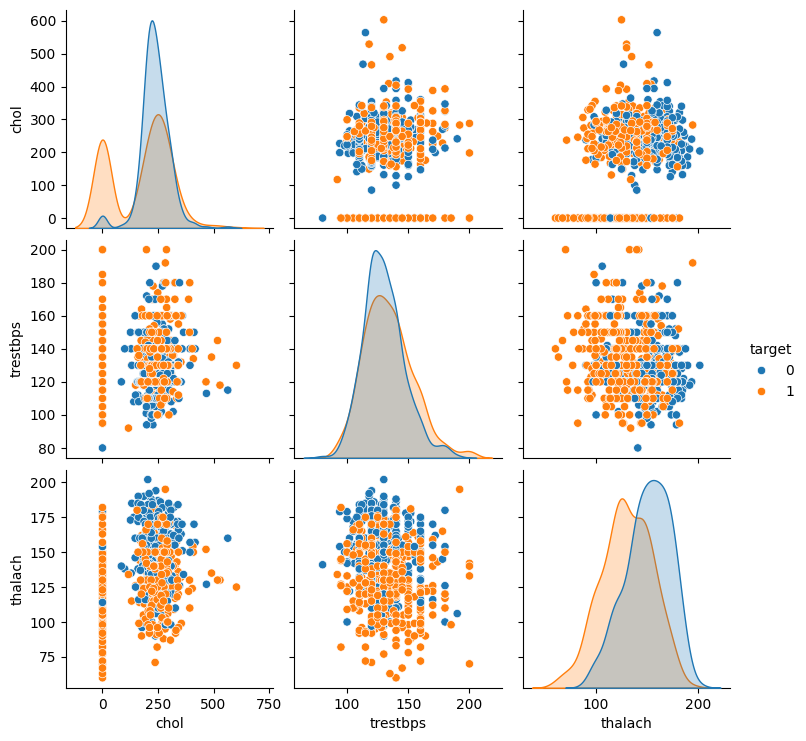

In [233]:
#Pairplot (Optional)
sns.pairplot(
    heart[
        [
            "age",
            "chol",
            "trestbps",
            "thalach",
            "target"
        ]
    ],
    hue="target"
)

plt.show()

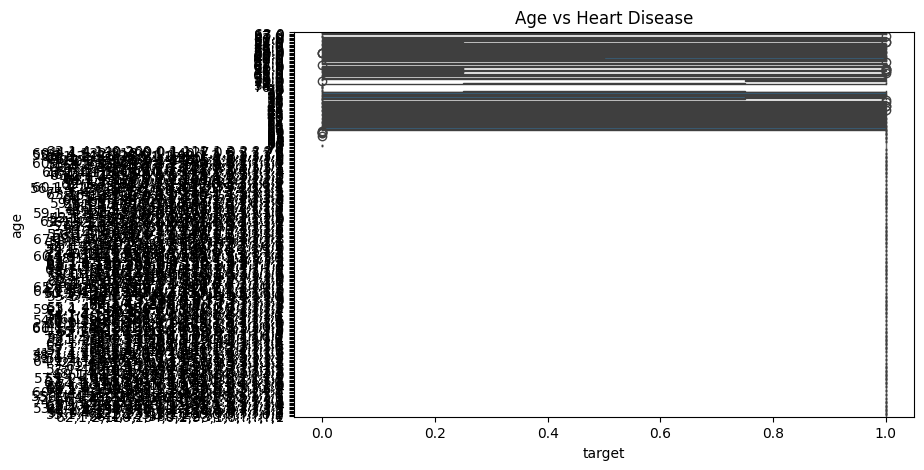

In [234]:
#Disease by Age
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="age",
    data=heart
)

plt.title("Age vs Heart Disease")

plt.show()

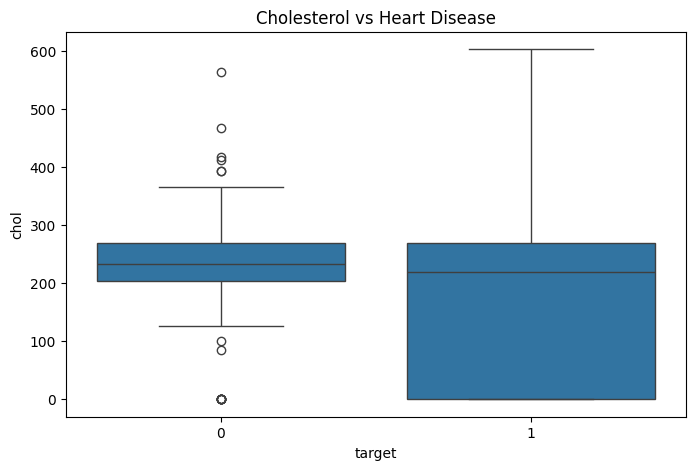

In [235]:
#Disease by Cholesterol
plt.figure(figsize=(8,5))

sns.boxplot(
    x="target",
    y="chol",
    data=heart
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

Feature Engineering

Load the cleaned dataset

Create Age Groups

Cholesterol Category

Blood Pressure Category

Interaction Features

Heart Rate Ratio

Verify New Features

Check for Missing Values

Save the Feature-Engineered Dataset



In [256]:
heart = pd.read_csv("heart_disease_cleaned.csv")

# Ensure 'age' column is numeric
heart["age"] = pd.to_numeric(heart["age"], errors='coerce')
# Fill any NaNs that might have been introduced during coercion
heart["age"] = heart["age"].fillna(heart["age"].median())

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


In [238]:
#Cholesterol Category
'''Clinical reference values:

Normal: < 200
Borderline: 200–239
High: ≥ 240'''
heart["Chol_Category"] = pd.cut(
    heart["chol"],
    bins=[0, 199, 239, 700],
    labels=[
        "Normal",
        "Borderline",
        "High"
    ]
)
heart["Chol_Category"].value_counts()

,count
Chol_Category,
High,296
Borderline,176
Normal,102


In [239]:
#Blood Pressure Category
#Using resting blood pressure:
heart["BP_Category"] = pd.cut(
    heart["trestbps"],
    bins=[0, 120, 129, 139, 300],
    labels=[
        "Normal",
        "Elevated",
        "Stage1",
        "Stage2"
    ]
)
heart["BP_Category"].value_counts()

,count
BP_Category,
Stage2,255
Normal,254
Stage1,148
Elevated,59


In [245]:
#Interaction Features
'''These combine two existing variables.'''

#Age × Cholesterol'''
heart["Age_Chol"] = heart["age"] * heart["chol"]
#'''Age × Blood Pressure'''
heart["Age_BP"] = heart["age"] * heart["trestbps"]
#Cholesterol × Blood Pressure
heart["Chol_BP"] = heart["chol"] * heart["trestbps"]

TypeError: can't multiply sequence by non-int of type 'float'

In [246]:
#Heart Rate Ratio
heart["HeartRate_Age"] = heart["thalach"] / heart["age"]

TypeError: unsupported operand type(s) for /: 'float' and 'str'

In [247]:
#Verify New Features
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset,Chol_Category,BP_Category
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,Borderline,Stage2
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland,High,Stage2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,Borderline,Normal
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,High,Stage1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,Borderline,Stage1


In [248]:
#Check for Missing Values
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,202
chol,221
fbs,0
restecg,0
thalach,201
exang,0
oldpeak,205


In [249]:
#Save the Feature-Engineered Dataset
heart.to_csv("heart_disease_feature_engineered.csv", index=False)

In [250]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset,Chol_Category,BP_Category
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,Borderline,Stage2
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland,High,Stage2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,Borderline,Normal
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,High,Stage1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,Borderline,Stage1


In [251]:
print(heart.shape)

(918, 17)


In [257]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,202
chol,221
fbs,0
restecg,0
thalach,201
exang,0
oldpeak,205


In [258]:
print(heart["dataset"].value_counts())

dataset
Cleveland      303
Hungarian      293
VA             199
Switzerland    123
Name: count, dtype: int64


In [259]:
print("Duplicate rows:", heart.duplicated().sum())

Duplicate rows: 198


Data Preprocessing

Encode categorical features

Split Features and Target

Train-Test Split

Feature Scaling

Check Class Imbalance

Apply SMOTE (if needed)


[ ]


In [260]:
heart = pd.read_csv("heart_disease_feature_engineered.csv")

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,dataset,Chol_Category,BP_Category
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland,Borderline,Stage2
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Cleveland,High,Stage2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland,Borderline,Normal
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland,High,Stage1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland,Borderline,Stage1


In [261]:
#Check Data Types
heart.dtypes

,0
age,object
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [262]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

heart["Age_Group"] = encoder.fit_transform(heart["Age_Group"])

heart["Chol_Category"] = encoder.fit_transform(heart["Chol_Category"])

heart["BP_Category"] = encoder.fit_transform(heart["BP_Category"])

KeyError: 'Age_Group'

In [ ]:
heart.head()

In [252]:
#Define X and y
# Remove:
# target
# dataset
X = heart.drop(columns=["target", "dataset"])
y = heart["target"]

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (918, 15)
Shape of y: (918,)


In [253]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (734, 15)
Shape of X_test: (184, 15)
Shape of y_train: (734,)
Shape of y_test: (184,)


In [ ]:
#Feature Scaling
'''This is important for:

SVM
KNN
Logistic Regression'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
#Check Class Distribution
print(y_train.value_counts())

In [ ]:
#Save the Preprocessed Data
import joblib

joblib.dump(scaler, "scaler.pkl")

In [ ]:
Train Multiple Machine Learning Models

Logistic Regression

Decision Tree

Random Forest

Support Vector Machine (SVM)

K-Nearest Neighbors (KNN)

XGBoost

LightGBM



In [ ]:
#Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
#Install Libraries
!pip install xgboost lightgbm

In [ ]:
#Import Them
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
#Create All Models
models = {

    "Logistic Regression":
    LogisticRegression(random_state=42),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "SVM":
    SVC(probability=True, random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "XGBoost":
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM":
    LGBMClassifier(random_state=42)

}

In [ ]:
#Train Every Model
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({

        "Model": name,

        "Accuracy":
        accuracy_score(y_test, y_pred),

        "Precision":
        precision_score(y_test, y_pred),

        "Recall":
        recall_score(y_test, y_pred),

        "F1 Score":
        f1_score(y_test, y_pred),

        "ROC AUC":
        roc_auc_score(y_test, y_prob)

    })


In [ ]:
#Display Results
results_df = pd.DataFrame(results)

results_df

In [ ]:
#Sort by Accuracy
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

In [ ]:
results_df

In [ ]:
print(heart["target"].value_counts())

In [ ]:
print(y_train.value_counts())

Hyperparameter Tuning

Import GridSearchCV

Create the Model

Define the Parameter Grid

Perform Grid Search

Best Parameters

Best Cross-Validation Accuracy

Test the Tuned Model

Calculate the New Accuracy


[ ]


In [ ]:
#Import GridSearchCV
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

In [ ]:
#Create the Model
lgbm = LGBMClassifier(random_state=42)

In [ ]:
#Define the Parameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "num_leaves": [15, 31, 50]
}

In [ ]:
#Perform Grid Search
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

In [ ]:
#Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

In [ ]:
#Best Cross-Validation Accuracy
print("Best CV Accuracy:", grid_search.best_score_)

In [ ]:
#Test the Tuned Model
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [ ]:
#Calculate the New Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy after tuning: {accuracy*100:.2f}%")

In [ ]:
heart.to_csv("heart_disease_feature_engineered.csv", index=False)

In [ ]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

Fold Cross Validation

Import

Cross Validation on the Best Model

Print Results

Visualize the Scores



In [ ]:
#Import
from sklearn.model_selection import cross_val_score

In [ ]:
from lightgbm import LGBMClassifier

best_lgb = LGBMClassifier(random_state=42)

In [ ]:
cv_scores = cross_val_score(
    best_lgb,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

In [199]:
#Print Results
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.67934783 0.54891304 0.75       0.85245902 0.78142077]

Average Accuracy:
0.7224281301971965

Standard Deviation:
0.10306480316278195


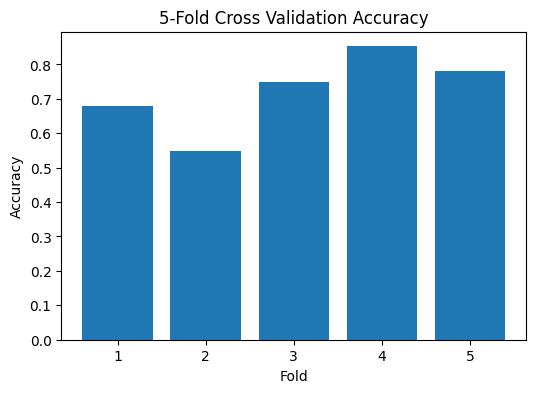

In [200]:
plt.figure(figsize=(6,4))
plt.bar(range(1, 6), cv_scores)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.show()

Ensemble Learning

Import VotingClassifier

Create Base Models

Build the Voting Classifier

Train the Ensemble

Predict

Evaluate

Compare All Models

In [201]:
#Import VotingClassifier
from sklearn.ensemble import VotingClassifier

In [202]:
voting_model = VotingClassifier(
    estimators=[
        ("rf", models["Random Forest"]),
        ("xgb", models["XGBoost"]),
        ("lgb", models["LightGBM"])
    ],
    voting="soft"
)

KeyError: 'XGBoost'

In [ ]:
rf = RandomForestClassifier(random_state=42)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

lgb = LGBMClassifier(random_state=42)

voting_model = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("lgb", lgb)
    ],
    voting="soft"
)

In [ ]:
voting_model.fit(X_train, y_train)

y_pred = voting_model.predict(X_test)
y_prob = voting_model.predict_proba(X_test)[:, 1]

In [ ]:
rf = RandomForestClassifier(random_state=42)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

lgb = LGBMClassifier(random_state=42)

In [ ]:
#Train the Ensemble
voting_model.fit(X_train, y_train)

In [ ]:
#Predict
y_pred = voting_model.predict(X_test)

y_prob = voting_model.predict_proba(X_test)[:,1]

In [ ]:
#Evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

In [ ]:
#Compare All Models
results_df.loc[len(results_df)] = [
    "Voting Classifier",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
]

results_df.sort_values(by="Accuracy", ascending=False)

Model Evaluation

Import Libraries

Confusion Matrix

Plot Confusion Matrix

Classification Report

ROC Curve

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

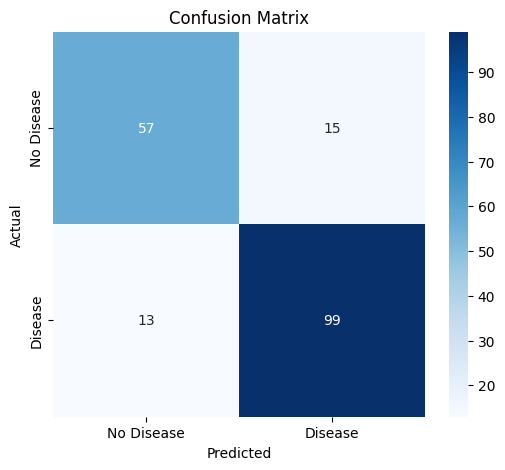

In [203]:
#Plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease','Disease'],
    yticklabels=['No Disease','Disease']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [204]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [205]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [61, 184]

Explainable AI using SHAP

Install SHAP

Import Libraries

Create SHAP Explainer

Calculate SHAP Values

SHAP Summary Plot

Feature Importance Plot

Explain One Patient

In [ ]:
#Install SHAP
!pip install shap

In [ ]:
#Import Libraries
import shap

In [ ]:
#Create SHAP Explainer
explainer = shap.TreeExplainer(best_model)

In [ ]:
print(type(X_test))

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
X_test_df = X_test

In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_df)

In [ ]:
shap_values = explainer.shap_values(X_test_df)

In [206]:
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>


In [207]:
print(type(best_model))

<class 'lightgbm.sklearn.LGBMClassifier'>


In [208]:
shap_values = explainer.shap_values(X_test_df)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


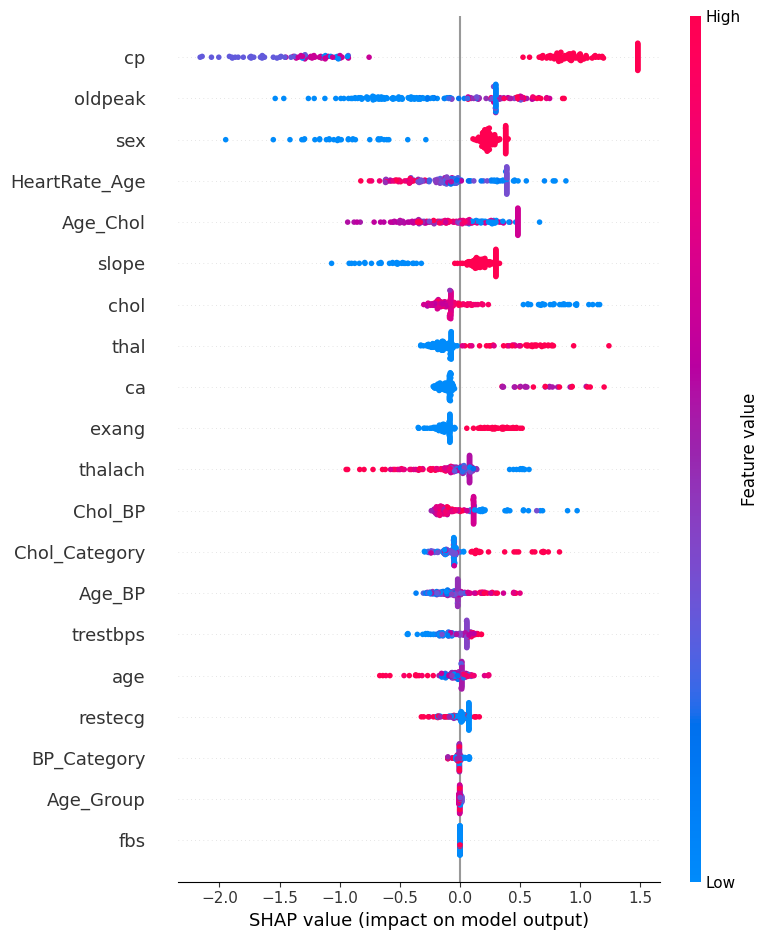

In [209]:
shap.summary_plot(shap_values, X_test_df)

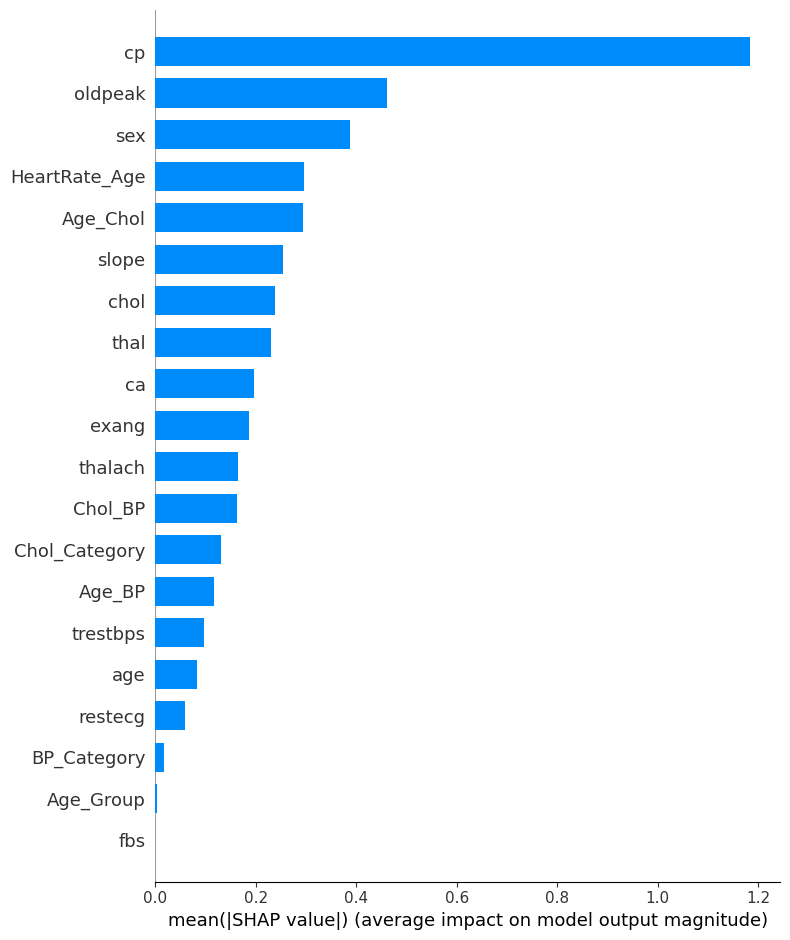

In [210]:
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar"
)

In [211]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [212]:
print(type(X_test_df))

<class 'pandas.core.frame.DataFrame'>


In [213]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test_df)

shap.plots.waterfall(shap_values[0])

LightGBMError: The number of features in data (13) is not the same as it was in training data (20).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_df)

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_df.iloc[0]
)

In [ ]:
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["age", "chol"]
)

plt.show()

In [ ]:
joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

In [ ]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["age"]
)

plt.show()

In [ ]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["chol"]
)

plt.show()

In [ ]:
PartialDependenceDisplay.from_estimator(
    best_model,
    X_test_df,
    ["trestbps"]
)

plt.show()

In [ ]:
joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully!")

In [ ]:
from google.colab import files

files.download("heart_disease_model.pkl")
files.download("scaler.pkl")

In [ ]:
pip install streamlit

In [ ]:
print(X.columns.tolist())

In [ ]:
joblib.dump(best_model, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl")

In [ ]:
import os

print(os.listdir())

In [ ]:
print("Model size:", os.path.getsize("heart_disease_model.pkl"))
print("Scaler size:", os.path.getsize("scaler.pkl"))

In [ ]:
from google.colab import files

files.download("heart_disease_model.pkl")

In [ ]:
from google.colab import files

files.download("scaler.pkl")